# 01 - hex_proximity_plot()

This notebook __creates function hex_proximity_plot()__ based on existing hex_plot() function.

## __Import libraries__

In [1]:
from pathlib import Path

current_path = Path().resolve()

for parent in current_path.parents:
    if parent.name == "odc":
        project_root = parent
        break

print(project_root)

/home/jovyan/odc


In [2]:
import os
import sys

import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
# Import logo image
import matplotlib.image as mpimg
# Place logo image above plot
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# Wrap title text inside plots
from textwrap import wrap

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

module_path = os.path.abspath(os.path.join(project_root))
if module_path not in sys.path:
    sys.path.append(module_path)
    print("Path found")
    import odc

Path found


## __Config notebook__

In [3]:
res = 8
city = 'Aguascalientes'

## __Load data__

In [4]:
# Load data test
data_schema = 'prox_analysis'
data_table = f'proximityanalysis_v2_23_mzaageb_hex'
# Load city's hexs filtering for urban areas if required
query = f"SELECT * FROM {data_schema}.{data_table} WHERE \"city\" = '{city}\' AND \"res\" = '{res}\'"
data_gdf = odc.gdf_from_query(query, geometry_col='geometry')

# Show
print(data_gdf.crs)
print(data_gdf.shape)
data_gdf.head(2)

epsg:4326
(326, 69)


,hex_id,res,geometry,max_escuelas,max_preescolar,max_primaria,max_secundaria,max_servicios comunitarios,max_salud,max_guarderías,...,pobmas,p_0a5,p_6a11,p_12a17,p_18a24,p_25a59,p_60ymas,pcon_disc,dens_pob_ha,city
0,88498e3663fffff,8,"POLYGON ((-102.25507 21.87373, -102.25048 21.8...",19.555528,9.509851,10.855071,19.555528,15.093313,9.821487,10.963312,...,1848.5159,335.58023,333.89948,316.66147,421.74573,1794.56247,702.35020,329.46800,45.210681,Aguascalientes
1,88498e3455fffff,8,"POLYGON ((-102.25547 21.92880, -102.25087 21.9...",11.626070,10.694301,6.959306,11.626070,44.004748,9.532449,9.070579,...,6153.3457,1475.07596,1778.80790,1803.25476,1425.95680,5503.76543,471.98077,702.15735,144.291588,Aguascalientes


In [5]:
data_gdf.columns

Index(['hex_id', 'res', 'geometry', 'max_escuelas', 'max_preescolar',
       'max_primaria', 'max_secundaria', 'max_servicios comunitarios',
       'max_salud', 'max_guarderías', 'max_asistencia social', 'max_comercio',
       'max_alimentos', 'max_personal', 'max_farmacias', 'max_hogar',
       'max_complementarios', 'max_entretenimiento', 'max_social',
       'max_actividad física', 'max_cultural', 'escuelas_15min',
       'preescolar_15min', 'primaria_15min', 'secundaria_15min',
       'servicios comunitarios_15min', 'salud_15min', 'guarderías_15min',
       'asistencia social_15min', 'comercio_15min', 'alimentos_15min',
       'personal_15min', 'farmacias_15min', 'hogar_15min',
       'complementarios_15min', 'entretenimiento_15min', 'social_15min',
       'actividad física_15min', 'cultural_15min', 'idx_preescolar',
       'idx_primaria', 'idx_secundaria', 'idx_salud', 'idx_guarderías',
       'idx_asistencia social', 'idx_alimentos', 'idx_personal',
       'idx_farmacias', 'idx_h

In [6]:
# Download area of interest (aoi)
print('--- Downloading area of interest.')
metro_schema = 'metropolis'
metro_table = 'metro_gdf_2020'
query = f"SELECT * FROM {metro_schema}.{metro_table} WHERE \"city\" LIKE \'{city}\'"
mun_gdf = odc.gdf_from_query(query, geometry_col='geometry')

# Create area of interest from dissolved municipalities
mun_gdf.to_crs("EPSG:6372",inplace=True)
aoi = mun_gdf.buffer(5)
aoi_gdf = gpd.GeoDataFrame(geometry=aoi,crs="EPSG:6372").dissolve()
aoi_gdf.to_crs("EPSG:4326",inplace=True)

# Download Network (G, nodes, edges)
print('--- Downloading network.')
network_schema = 'osmnx'
nodes_table = 'nodes_osmnx_23_point'
edges_table = 'edges_speed_23_line'
G, nodes_gdf, edges_gdf = odc.graph_from_hippo(aoi, schema=network_schema, edges_folder=edges_table, nodes_folder=nodes_table)

# Show
print(edges_gdf.crs)
print(edges_gdf.shape)
edges_gdf.head(2)

--- Downloading area of interest.
--- Downloading network.
EPSG:4326
(128150, 19)


osmid  oneway                   name  \
u          v          key                                             
8414611560 1729024510 0    906116849   False  Boulevard Guadalupano   
           2304455693 0    906116850    True  Boulevard Guadalupano   

                             highway  length  \
u          v          key                      
8414611560 1729024510 0    secondary  53.013   
           2304455693 0    secondary  11.792   

                                                                    geometry  \
u          v          key                                                      
8414611560 1729024510 0    LINESTRING (-102.25354 21.91028, -102.25343 21...   
           2304455693 0    LINESTRING (-102.25354 21.91028, -102.25353 21...   

                           grade  grade_abs lanes bridge maxspeed     ref  \
u          v          key                                                   
8414611560 1729024510 0   -0.038      0.038     3   None     None  AGS 60   
           2304455693 0    0.000      0.000     3   None       40  AGS 60   

                          access junction service tunnel width  walkspeed  \
u          v          key                                                   
8414611560 1729024510 0     None     None    None   None  None    3.50186   
           2304455693 0     None     None    None   None  None    4.00000   

                           time_min  
u          v          key            
8414611560 1729024510 0    0.908311  
           2304455693 0    0.176880

## __Function development__

In [7]:
"""
This function creates a plot designed to show proximity analysis values.

Arguments:
     gdf_data (geopandas.GeoDataFrame): GeoDataFrame with the data to be plotted.
     column (str): Name of the column to plot from the gdf_data GeoDataFrame.
     location_name (str): Name of the location (to be added on the plot title).
     ax (matplotlib.axes): ax to use in the plot.

Keyword Arguments:
    plot_osmnx_edges (tuple, optional): Tuple containing boolean on position [0].
                                        If true, a gdf can be specified on position [1]. 
                                        The gdf must contain edges from Open Street Map with a column named 'highway' since the edges are shown according 'highway' values.
                                        Defaults to (False, '')
    plot_boundary (tuple, optional): Tuple containing boolean on position [0]. 
                                     If true, a gdf can be specified on position [1] and a boundary is ploted.
                                     Defaults to (False, '')
    save_png (tuple, optional): Tupple containing boolean on position [0].
                                If true, a string can be specified on position [1] indicating the directory and file name where the png is saved.
                                Defaults to (False, '../output/figures/plot.png')
    png_transparency (bool): Saves the png with transparency or not. Defaults to False.
    png_dpi (int): Sets the resolution to be used to save the png. Defaults to 300.
    save_pdf (tuple, optional): Tupple containing boolean on position [0].
                                If true, a string can be specified on position [1] indicating the directory and file name where the pdf is saved.
                                Defaults to (False, '../output/figures/plot.pdf') 
"""

"\nThis function creates a plot designed to show proximity analysis values.\n\nArguments:\n     gdf_data (geopandas.GeoDataFrame): GeoDataFrame with the data to be plotted.\n     column (str): Name of the column to plot from the gdf_data GeoDataFrame.\n     location_name (str): Name of the location (to be added on the plot title).\n     ax (matplotlib.axes): ax to use in the plot.\n\nKeyword Arguments:\n    plot_osmnx_edges (tuple, optional): Tuple containing boolean on position [0].\n                                        If true, a gdf can be specified on position [1]. \n                                        The gdf must contain edges from Open Street Map with a column named 'highway' since the edges are shown according 'highway' values.\n                                        Defaults to (False, '')\n    plot_boundary (tuple, optional): Tuple containing boolean on position [0]. \n                                     If true, a gdf can be specified on position [1] and a boundary 

In [55]:
def plot_hex_proximity(gdf_data, column, location_name, ax,
                       plot_osmnx_edges = (False, ''),
                       plot_boundary = (False, ''),
                       save_png = (False, '../output/figures/plot.png'),
                       png_transparency = False,
                       png_dpi = 300,
                       save_pdf = (False, '../output/figures/plot.pdf'),
                      ):
    
    # --------------- DIVIDE THE PLOT
    if ('min' in column) or ('idx' in column):
        # Create a divider for the provided ax
        divider = odc.make_axes_locatable(ax)
        # Create an axe for the colorbar (which has cax=cax). 
        # The size will be the "size%" of the main ax, while there's a spacing (pad) between the main ax and the colorbar
        cax = divider.append_axes("bottom", size="5%", pad=0.1)
    
    # --------------- PLOT PROXIMITY DATA (Amenity availability (count), proximity index (idx) or time data)
    data_linestyle = '-'
    data_linewidth = 0.35
    data_edgecolor = 'white'
    
    # Plot amenity availability (count) data
    # (e.g. column 'cultural_15min', which indicates the average number of kindergardens on a 15 minutes walk by hex)
    if 'min' in column:
        # Extract amenity name
        amenity_name = column.split('_')[0]
        # Extract time used for availability calculation (normaly 15 minutes)
        time_amount = column.split('_')[1]
        # Create plot title
        plot_title = f"Availability of {amenity_name} amenities on a {time_amount} walk in {location_name.capitalize()}."
        # Plot proximity data using the viridis color palette (Commonly used for proximity data)
        gdf_data.plot(ax=ax,column=column,cmap='viridis',legend=True,cax=cax,legend_kwds={'label':column,'orientation': "horizontal"},linestyle=data_linestyle,linewidth=data_linewidth,edgecolor=data_edgecolor,zorder=1)         
    
    # Plot proximity index (idx) data
    # (e.g. column 'idx_preescolar', which indicates the proximity index (using a sigmodial function) for kindergardens)
    elif 'idx' in column:
        # Set plot title
        if column == 'idx_sum': #All-amenities index
            plot_title = f"Proximity index (Sigmodial) for all amenities in {location_name.capitalize()}."
        else: # Index to specific amenity
            # Extract amenity name
            amenity_name = column.split('_')[1]
            plot_title = f"Proximity index (Sigmodial) for {amenity_name} amenities in {location_name.capitalize()}."
        # Plot proximity data using the viridis color palette (Commonly used for proximity data)
        gdf_data.plot(ax=ax,column=column,cmap='cividis',legend=True,cax=cax,legend_kwds={'label':column,'orientation': "horizontal"},linestyle=data_linestyle,linewidth=data_linewidth,edgecolor=data_edgecolor,zorder=1)
    
    # Plot time data
    # (e.g. columns 'max_preescolar' or 'median_time', which indicates average time (minutes) data and is categorized in time bins)
    elif ('max' in column) or ('time' in column):
         # Set plot title
        if 'time' in column: #Time to all amenities
            # Extract statistical selected (Can be mean_time, median_time or max_time)
            statistical = column.split('_')[0]
            plot_title = f"Proximity analysis showing {statistical} time to all amenities in {location_name.capitalize()}."
        else: # Time to specific amenity
            # Extract amenity name
            amenity_name = column.split('_')[1]
            plot_title = f"Time to {amenity_name} amenities in {location_name.capitalize()}."
        # Categorize time data in time bins
        gdf_data.loc[gdf_data[column]>=60 , f'{column}_cat'] = '60 or more minutes'
        gdf_data.loc[(gdf_data[column]>=45 )&
                     (gdf_data[column]<60), f'{column}_cat'] = '45 minutes to 60 minutes'
        gdf_data.loc[(gdf_data[column]>=30)&
                     (gdf_data[column]<45), f'{column}_cat'] = '30 minutes to 45 minutes'
        gdf_data.loc[(gdf_data[column]>=15)&
                     (gdf_data[column]<30), f'{column}_cat'] = '15 minutes to 30 minutes'
        gdf_data.loc[(gdf_data[column]<15), f'{column}_cat'] = '15 minutes or less'
        
        # Order data
        categories = ['15 minutes or less','15 minutes to 30 minutes','30 minutes to 45 minutes','45 minutes to 60 minutes','60 or more minutes']
        gdf_data[f'{column}_cat'] = pd.Categorical(gdf_data[f'{column}_cat'], categories=categories, ordered=True)

        # Plot proximity data using the viridis color palette (Commonly used for proximity data)
        gdf_data.plot(ax=ax,column=f'{column}_cat',cmap='viridis_r',legend=True,legend_kwds={'loc':'lower left'},linestyle=data_linestyle,linewidth=data_linewidth,edgecolor=data_edgecolor,zorder=1)

    # --------------- PLOT OPTIONAL COMPLEMENTS (Area of interest boundary and streets)
    # Plot boundary
    if plot_boundary[0]:
        boundary_gdf = plot_boundary[1].copy()
        boundary_gdf.boundary.plot(ax=ax,color='#bebebe',linestyle='--',linewidth=0.5,zorder=2) #2b2b2b
    
    # Plot edges (Main)
    if plot_osmnx_edges[0]:
        gdf_edges = plot_osmnx_edges[1].copy()
        edges_shown_a = ['trunk','trunk_link','motorway','motorway_link']
        gdf_edges_main = gdf_edges[gdf_edges['highway'].isin(edges_shown_a)].copy()
        if len(gdf_edges_main) > 0:
            gdf_edges_main.plot(ax=ax,color='#000000',alpha=0.5,linewidth=1.0,zorder=3)
        # Plot edges (Primary and secondary)
        edges_shown_b = ['primary','primary_link']#,'secondary','secondary_link']
        gdf_edges_primary = gdf_edges[gdf_edges['highway'].isin(edges_shown_b)].copy()
        if len(gdf_edges_primary) > 0:
            gdf_edges_primary.plot(ax=ax,color='#000000',alpha=0.5,linewidth=0.50,zorder=3)
    
	# --------------- PLOT FORMAT
    
    # FORMAT - Calculate current ax width (Used in title text wrapping, legent text sizing and image zoom calculation)
    # NOTE: Must be located after plotting map elements since matplotlib updates the layout to the elements of present.
    fig = ax.figure
    fig.canvas.draw()  # Opens canvas in order to measure real size
    renderer = fig.canvas.get_renderer()
    bbox = ax.get_window_extent(renderer=renderer)
    ax_width_px = bbox.width
    
    # FORMAT - Wrap title text
    # Calculate fontsize relative to ax width (Previously set fontsize = 12.5)
    fontsize = int(ax_width_px / 50)
    # Calculate aprox. number of characters that fit inside half the ax size 
    # (Chose 0.40 instead of 0.50 because the text doesn't start exactly over the left axis)
    char_width_px = fontsize * 0.6  # Average size that a character occupies (in pixels)
    max_chars = int((ax_width_px * 0.40) / char_width_px)
    # Wrap tittle
    wrapped_title = "\n".join(wrap(plot_title, width=max_chars))
    
    # FORMAT - Set title
    ax.text(0.03, 0.98, wrapped_title,
            fontsize=fontsize, 
            fontweight='bold',
            ha='left', va='top', # Text allignment
            transform=ax.transAxes, #ax.tramsAxes sets position relative to axes instead of coordinates
            #bbox=dict(facecolor='white', edgecolor='none', # Create semi-transparent box around text [Canceled]
            #          alpha=0.75, boxstyle='round,pad=0.3') 
           )

    # FORMAT - Edit legend text size
    # Modify categorized legend, which is a matplotlib.legend.Legend and can be accessed using ax.get_legend()
    legend_fontsize = int(ax_width_px / 75)
    if ('max' in column) or ('time' in column):
        legend = ax.get_legend()
        legend.set_title(column)
        legend.get_title().set_fontsize(legend_fontsize)
        legend.get_title().set_fontweight('bold')
        for text in legend.get_texts():
            text.set_fontsize(legend_fontsize)
    # Modify colorbar (not a legent, and is controled by using cax=cax)
    # [Solution doesn't work yet. If required, must define cmap and normalization manualy before plot, then plot without atutomatic legend and passing cmap, finaly create colormap manualy and editing colorbar]
    # [Saved chatgpt conversation with solution as OdC - Format legent text sizes]
    #else:
        # Retrieve colorbar object (matplotlib.colorbar.Colorbar)
    #    cbar = cax.collections[0].colorbar
        # Change colorbar tick size
    #    cbar.ax.tick_params(labelsize=legend_fontsize)
        # Change colorbar label
    #    cbar.set_label(column, fontsize=legend_fontsize)
        
    # FORMAT - Set grid [Canceled]
    #ax.grid(color='grey', linestyle='--', linewidth=0.25) 

    # FORMAT - Set image
    # Find current path to project
    from pathlib import Path
    current_path = Path().resolve()
    for parent in current_path.parents:
        if parent.name == "odc":
            project_root = parent
            break
    # Read image from dir starting in project_root
    img_dir = str(project_root)+'/data/external/odc_logo/LOGO OC_3.png'
    img = mpimg.imread(img_dir)
    # Calculate image zoom a) Get current image extent
    img_width_px = img.shape[1]
    # Calculate image zoom c) Calculate required zoom so that image occupies ~10% of ax size
    target_fraction = 0.05
    img_zoom = (ax_width_px * target_fraction) / img_width_px
    # Insert image on bottom right corner with specified zoom
    # (0,1) --> Upper left
    # (1,1) --> Upper right
    # (0,0) --> Lower left
    # (1,0) --> Lower right
    img_position = (0.98, 0.03)
    img_box = OffsetImage(img, zoom=img_zoom)
    ab = AnnotationBbox(img_box, img_position, frameon=False,
                        xycoords='axes fraction',  # Set coordinates relative to axis (e.g. (0,1))
                        box_alignment=img_position)  # Align image
    # Add image to ax
    ax.add_artist(ab)
    
    # --------------- SAVING CONFIGURATIONS
    # Save or show plot
    if save_png[0]:
        plt.savefig(save_png[1],dpi=png_dpi,transparent=png_transparency)
    if save_pdf[0]:
        plt.savefig(save_pdf[1])

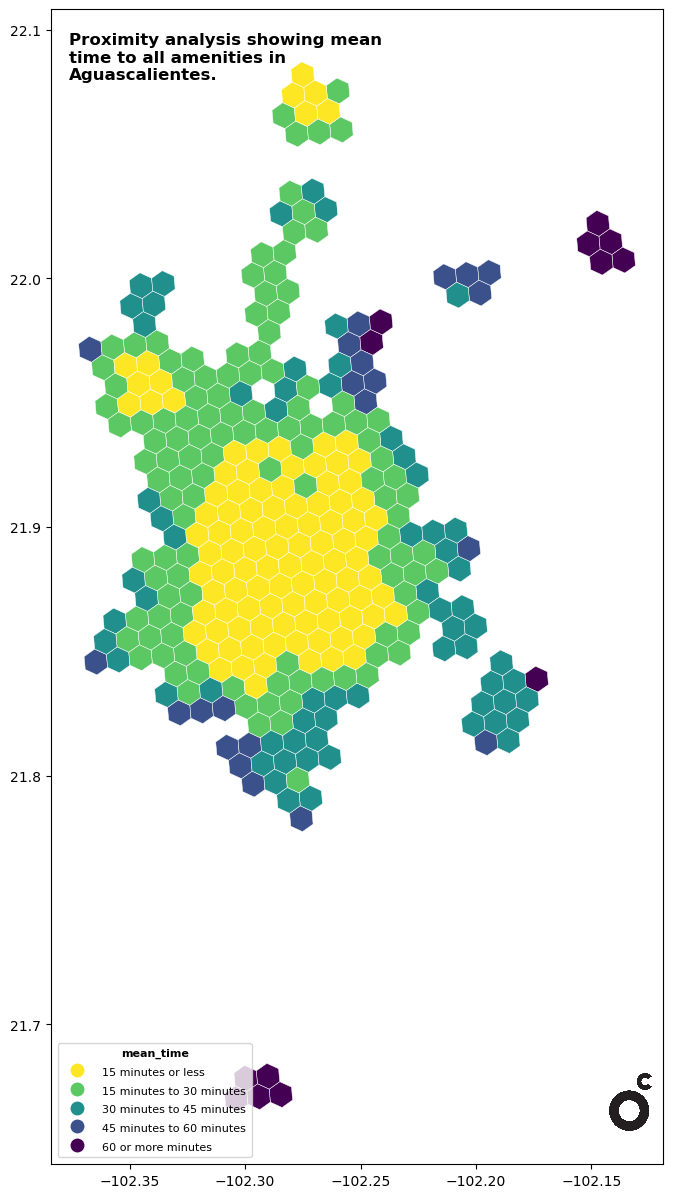

In [56]:
fig,ax = plt.subplots(figsize=(30,15))

# Time plot (cultural_15min)
plot_hex_proximity(gdf_data = data_gdf,
                   column = 'mean_time',
                   location_name = city,
                   ax=ax,
                  )

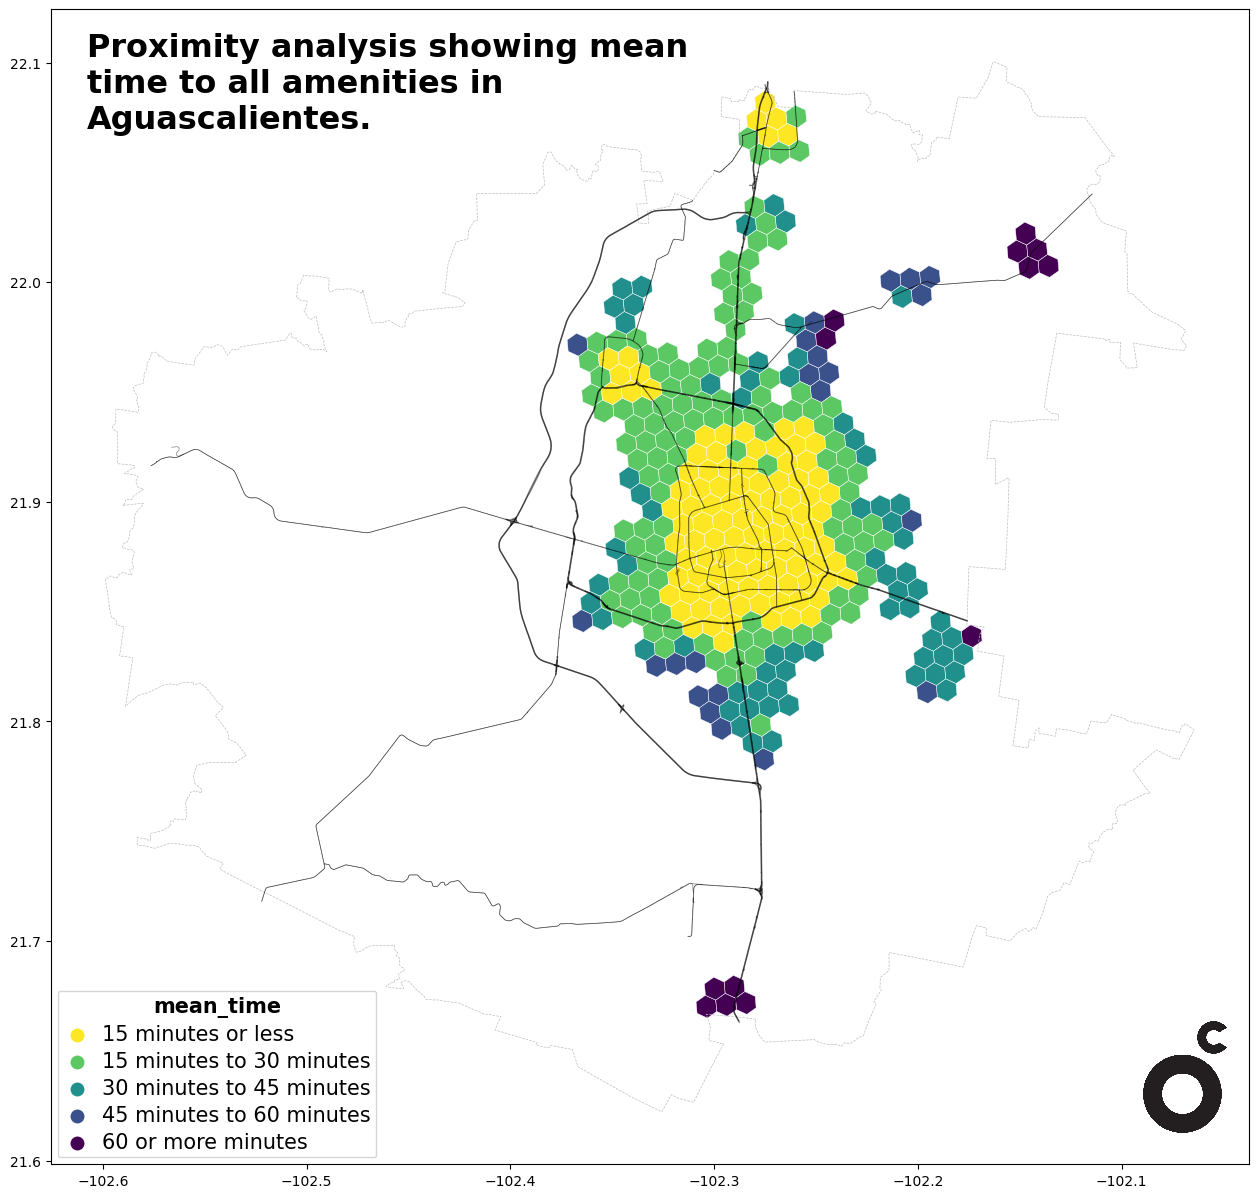

In [57]:
fig,ax = plt.subplots(figsize=(30,15))

# Time plot (mean_time)
plot_hex_proximity(gdf_data = data_gdf,
                   column = 'mean_time',
                   location_name = city,
                   ax=ax,
                   plot_osmnx_edges = (True, edges_gdf), #Kwarg
                   plot_boundary = (True, aoi_gdf), #Kwarg
                   save_png = (False, '../../output/figures/plot.png'), #Kwarg
                   png_transparency = False, #Kwarg
                   png_dpi = 300, #Kwarg
                   save_pdf = (False, '../../output/figures/plot.pdf') #Kwarg
                  )

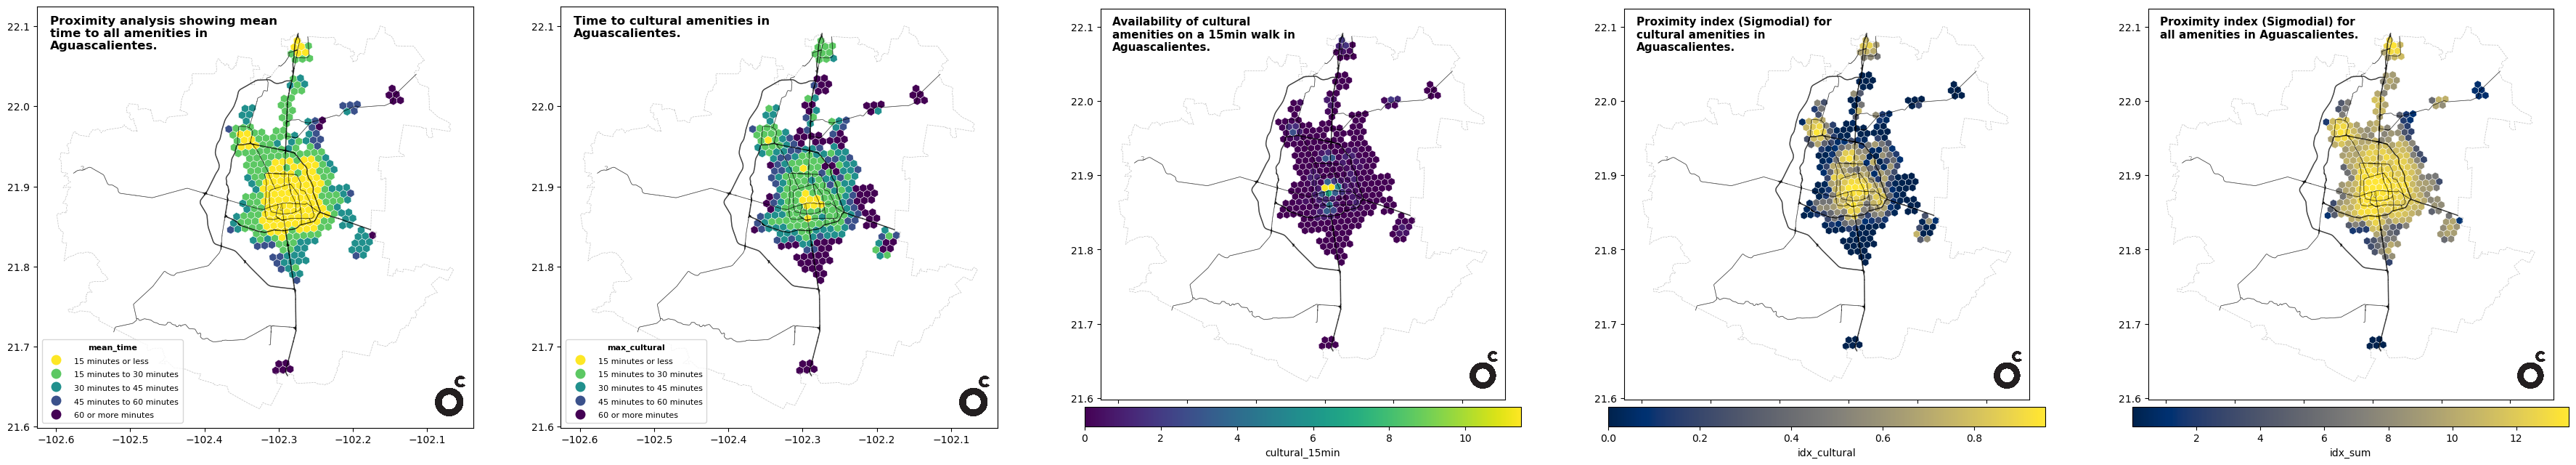

In [58]:
fig,axs = plt.subplots(1,5,figsize=(45,15))

# TIMES TEST
#mean_time
#max_cultural

# COUNT TEST
#cultural_15min

# INDEX TEST
#idx_cultural
#idx_sum

# Time plot (mean_time)
plot_hex_proximity(gdf_data = data_gdf,
                   column = 'mean_time',
                   location_name = city,
                   ax=axs[0],
                   plot_osmnx_edges = (True, edges_gdf), #Kwarg
                   plot_boundary = (True, aoi_gdf), #Kwarg
                   save_png = (False, '../../output/figures/plot.png'), #Kwarg
                   png_transparency = False, #Kwarg
                   png_dpi = 300, #Kwarg
                   save_pdf = (False, '../../output/figures/plot.pdf') #Kwarg
                  )

# Time plot (max_cultural)
plot_hex_proximity(gdf_data = data_gdf,
                   column = 'max_cultural',
                   location_name = city,
                   ax=axs[1],
                   plot_osmnx_edges = (True, edges_gdf), #Kwarg
                   plot_boundary = (True, aoi_gdf), #Kwarg
                   save_png = (False, '../../output/figures/plot.png'), #Kwarg
                   png_transparency = False, #Kwarg
                   png_dpi = 300, #Kwarg
                   save_pdf = (False, '../../output/figures/plot.pdf') #Kwarg
                  )

# Count plot (cultural_15min)
plot_hex_proximity(gdf_data = data_gdf,
                   column = 'cultural_15min',
                   location_name = city,
                   ax=axs[2],
                   plot_osmnx_edges = (True, edges_gdf), #Kwarg
                   plot_boundary = (True, aoi_gdf), #Kwarg
                   save_png = (False, '../../output/figures/plot.png'), #Kwarg
                   png_transparency = False, #Kwarg
                   png_dpi = 300, #Kwarg
                   save_pdf = (False, '../../output/figures/plot.pdf') #Kwarg
                  )

# Index plot (idx_cultural)
plot_hex_proximity(gdf_data = data_gdf,
                   column = 'idx_cultural',
                   location_name = city,
                   ax=axs[3],
                   plot_osmnx_edges = (True, edges_gdf), #Kwarg
                   plot_boundary = (True, aoi_gdf), #Kwarg
                   save_png = (False, '../../output/figures/plot.png'), #Kwarg
                   png_transparency = False, #Kwarg
                   png_dpi = 300, #Kwarg
                   save_pdf = (False, '../../output/figures/plot.pdf') #Kwarg
                  )

# Index plot (idx_sum)
plot_hex_proximity(gdf_data = data_gdf,
                   column = 'idx_sum',
                   location_name = city,
                   ax=axs[4],
                   plot_osmnx_edges = (True, edges_gdf), #Kwarg
                   plot_boundary = (True, aoi_gdf), #Kwarg
                   save_png = (False, '../../output/figures/plot.png'), #Kwarg
                   png_transparency = False, #Kwarg
                   png_dpi = 300, #Kwarg
                   save_pdf = (False, '../../output/figures/plot.pdf') #Kwarg
                  )